# Tutorial 7 — Optical Parametric Amplification and Oscillation

We build up from single-pass OPA to a synchronously-pumped OPO,
adding **one physical effect at a time** so we can see what each does.

**Physics recap:**
- The QPM poling (pp=5.18 um) phase-matches 2 um ↔ 1 um
- SHG: pump at 2 um → SH at 1 um (Tutorial 5)
- OPA: pump at 1 um + seed at 2 um → amplified signal at 2 um
- OPO: pump at 1 um → self-starting signal at 2 um (with cavity feedback)

**Progression:**
1. Single-pass OPA (ideal, no noise)
2. Parametric fluorescence (add vacuum noise)
3. OPO with ideal cavity (add feedback, no loss)
4. Add cavity loss
5. Add output coupler
6. Effect of cavity detuning
7. Threshold scan

In [1]:
import numpy as np
from numpy.fft import fft, ifft, fftshift, fftfreq
import matplotlib.pyplot as plt
import time

import snow.pulses as pulses
import snow.waveguides as waveguides

from scipy.constants import pi, c
nm = 1e-9
um = 1e-6
mm = 1e-3
ps = 1e-12
fs = 1e-15
MHz = 1e6
THz = 1e12
pJ = 1e-12
uW = 1e-6
mW = 1e-3

plt.rcParams.update({'font.size': 14})

# --- Configuration ---
BACKEND = 'jax'        # 'scipy' for CPU, 'jax' for GPU
SHOW_TIMINGS = True     # print per-cell wall time
BENCHMARK = False       # if True, run both backends and compare

nee_kwargs = {}
if BACKEND == 'jax' or BENCHMARK:
    import jax.numpy as jnp
    nee_kwargs_jax = {'poling_fn_jax': lambda z: jnp.sign(jnp.cos(z * 2*jnp.pi / 5.18e-6))}
    if BACKEND == 'jax':
        nee_kwargs = nee_kwargs_jax

def run_nee(wg, pulse, v_ref, **extra_kwargs):
    """Run NEE with configured backend. If BENCHMARK, run both and compare."""
    merged = {**nee_kwargs, **extra_kwargs}

    t0 = time.perf_counter()
    out, steps = wg.propagate_NEE(pulse, v_ref=v_ref, verbose=False,
                                  backend=BACKEND, **merged)
    dt_primary = time.perf_counter() - t0

    if SHOW_TIMINGS:
        print(f'  [{BACKEND}] {dt_primary:.2f}s, {len(steps)} steps')

    if BENCHMARK:
        other = 'scipy' if BACKEND == 'jax' else 'jax'
        other_kw = {**extra_kwargs}
        if other == 'jax':
            other_kw.update(nee_kwargs_jax)
        t0 = time.perf_counter()
        out2, steps2 = wg.propagate_NEE(pulse, v_ref=v_ref, verbose=False,
                                        backend=other, **other_kw)
        dt_other = time.perf_counter() - t0
        corr = float(np.abs(np.sum(out.a * np.conj(out2.a))) /
                     np.sqrt(np.sum(np.abs(out.a)**2) * np.sum(np.abs(out2.a)**2)))
        print(f'  [{other}] {dt_other:.2f}s, {len(steps2)} steps, corr={corr:.6f}')

    return out, steps

print(f'Backend: {BACKEND}' + (' (benchmarking both)' if BENCHMARK else ''))

Backend: jax


## Grid and Waveguide

In [2]:
lam_start = 800*nm
lam_stop = 3*um
f_max = c/lam_start
f_min = c/lam_stop
BW = f_max - f_min
N = 2**10
dt = 1/BW
T = N/BW
t = -T/2 + np.arange(0, T, step=dt)
f = fftfreq(N, dt)
f_ref = (f_max + f_min)/2
f_abs = f + f_ref
frep = 250*MHz
pp = 5.18*um

def make_wg(L_val=4*mm):
    wg = waveguides.waveguide(w_top=1800*nm, h_thinfilm=700*nm, h_etch=350*nm,
                              tf_material='LN_MgO_e', box_material='SiO2', clad_material='Air')
    wg.add_poling(lambda z: np.sign(np.cos(z*2*pi/pp)))
    wg.set_nonlinear_coeffs(N=1, X0=1.1e-12)
    wg.set_length(L_val)
    wg.set_loss(0)
    return wg

wg = make_wg()
v_ref = 1/wg.beta1(1.5*um)

gvm = float(wg.beta1(1*um) - wg.beta1(2*um))
print(f'GVM between 1um and 2um: {gvm/(fs/mm):.1f} fs/mm')
print(f'Walkoff over 4mm crystal: {gvm*4*mm/fs:.0f} fs')

# Common OPO parameters used in later sections
f0_signal = c/(2*um)
signal_bw = 40*THz
Pavg_pump = 500*uW

GVM between 1um and 2um: 13.3 fs/mm
Walkoff over 4mm crystal: 53 fs


/tmp/ipykernel_2679427/144096579.py:28: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  gvm = float(wg.beta1(1*um) - wg.beta1(2*um))


## 1. Single-pass OPA (ideal)

The simplest case: pump at 1 um, weak coherent seed at 2 um, no noise.
Pure parametric gain — the seed is amplified, the pump is depleted.

Pump: 0.400 pJ,  Seed: 0.000040 pJ
  [jax] 7.43s, 366 steps
Signal gain: 52.1x (17.2 dB)


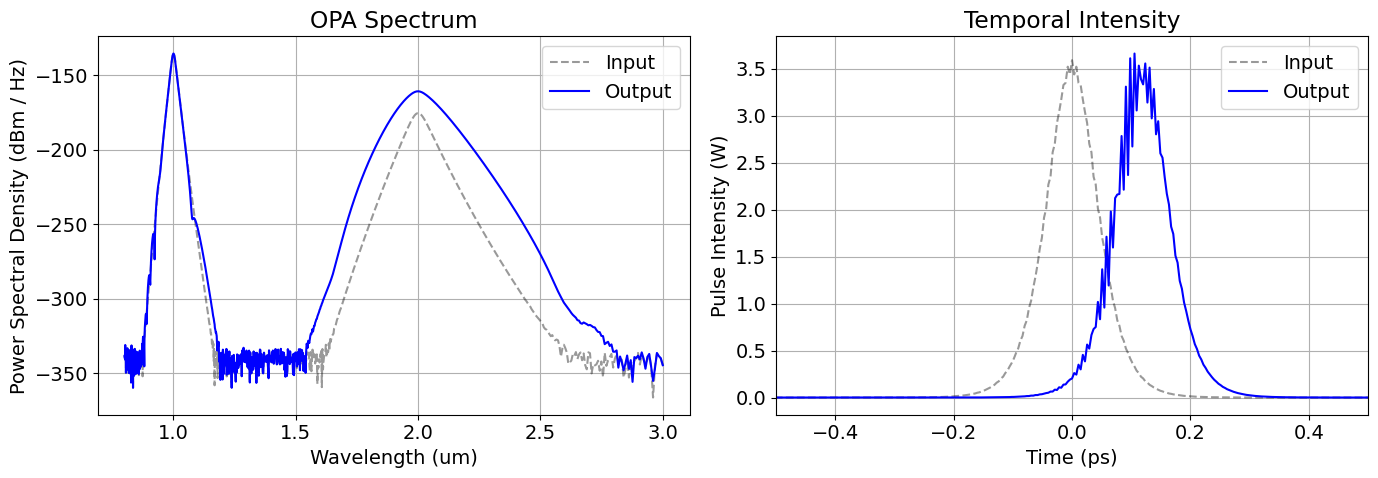

In [3]:
pump_opa = pulses.sech_pulse(t, 100*fs, f_ref=f_ref, f0=c/(1*um),
                             Pavg=100*uW, Npwr_dB=200, frep=frep)
seed = pulses.sech_pulse(t, 100*fs, f_ref=f_ref, f0=c/(2*um),
                         Pavg=0.01*uW, Npwr_dB=200, frep=frep)
input_opa = pump_opa + seed

print(f'Pump: {pump_opa.energy_td()/pJ:.3f} pJ,  Seed: {seed.energy_td()/pJ:.6f} pJ')
out_opa, _ = run_nee(wg, input_opa, v_ref)

sig_in = seed.apply_filter(f0_signal, signal_bw)
sig_out = out_opa.apply_filter(f0_signal, signal_bw)
gain = sig_out.energy_td() / sig_in.energy_td()
print(f'Signal gain: {gain:.1f}x ({10*np.log10(gain):.1f} dB)')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), tight_layout=True)
input_opa.plot_PSD(ax=ax1, f_unit='um')
out_opa.plot_PSD(ax=ax1, f_unit='um')
ax1.get_lines()[-2].set(color='k', linestyle='--', alpha=0.4, label='Input')
ax1.get_lines()[-1].set(color='b', linewidth=1.5, label='Output')
ax1.legend(); ax1.set_title('OPA Spectrum')

input_opa.plot_magsq(ax=ax2, t_unit='ps')
out_opa.plot_magsq(ax=ax2, t_unit='ps')
ax2.get_lines()[-2].set(color='k', linestyle='--', alpha=0.4, label='Input')
ax2.get_lines()[-1].set(color='b', linewidth=1.5, label='Output')
ax2.set_xlim(-0.5, 0.5)
ax2.legend(); ax2.set_title('Temporal Intensity')
plt.show()

## 2. Add vacuum noise — parametric fluorescence

Remove the coherent seed.  With `Qnoise=True`, half-photon-per-mode
vacuum fluctuation noise is added.  The parametric gain amplifies this
noise into a measurable signal — orders of magnitude weaker than the
seeded OPA, but it's the physical process that starts an OPO.

  [jax] 5.57s, 57 steps
Parametric fluorescence at 2um: 1.73e-05 pJ
Seeded OPA signal was:          2.08e-03 pJ
Ratio (seeded / spontaneous):   121x


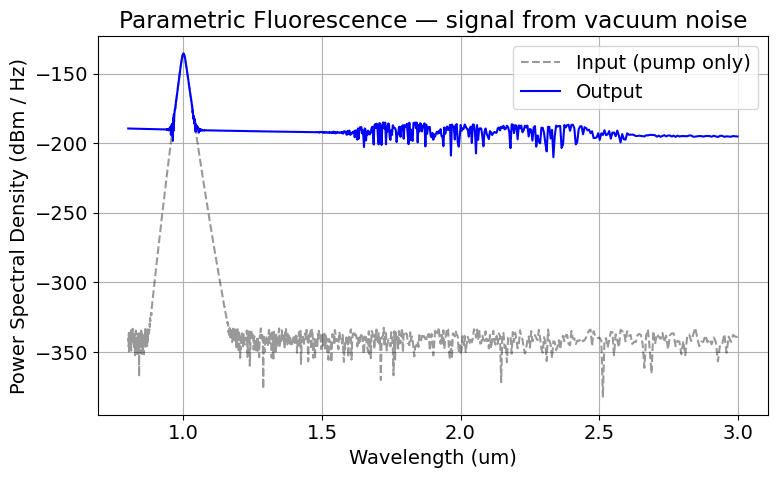

In [4]:
pump_pf = pulses.sech_pulse(t, 100*fs, f_ref=f_ref, f0=c/(1*um),
                            Pavg=100*uW, Npwr_dB=200, frep=frep)

out_pf, _ = run_nee(wg, pump_pf, v_ref, Qnoise=True)

sig_pf = out_pf.apply_filter(f0_signal, signal_bw)
print(f'Parametric fluorescence at 2um: {sig_pf.energy_td()/pJ:.2e} pJ')
try:
    print(f'Seeded OPA signal was:          {sig_out.energy_td()/pJ:.2e} pJ')
    print(f'Ratio (seeded / spontaneous):   {sig_out.energy_td()/sig_pf.energy_td():.0f}x')
except NameError:
    print('(Run OPA cell first to see comparison)')

fig, ax = plt.subplots(figsize=(8, 5), tight_layout=True)
pump_pf.plot_PSD(ax=ax, f_unit='um')
out_pf.plot_PSD(ax=ax, f_unit='um')
ax.get_lines()[-2].set(color='k', linestyle='--', alpha=0.4, label='Input (pump only)')
ax.get_lines()[-1].set(color='b', linewidth=1.5, label='Output')
ax.legend(); ax.set_title('Parametric Fluorescence — signal from vacuum noise')
plt.show()

## 3. Add feedback — ideal OPO cavity

Feed the 2 um signal back to the waveguide input with a fresh pump
each roundtrip.  **No loss, no outcoupling** — all signal returns.
The signal grows without bound until it depletes the pump.

Ideal cavity (100% feedback, no loss):


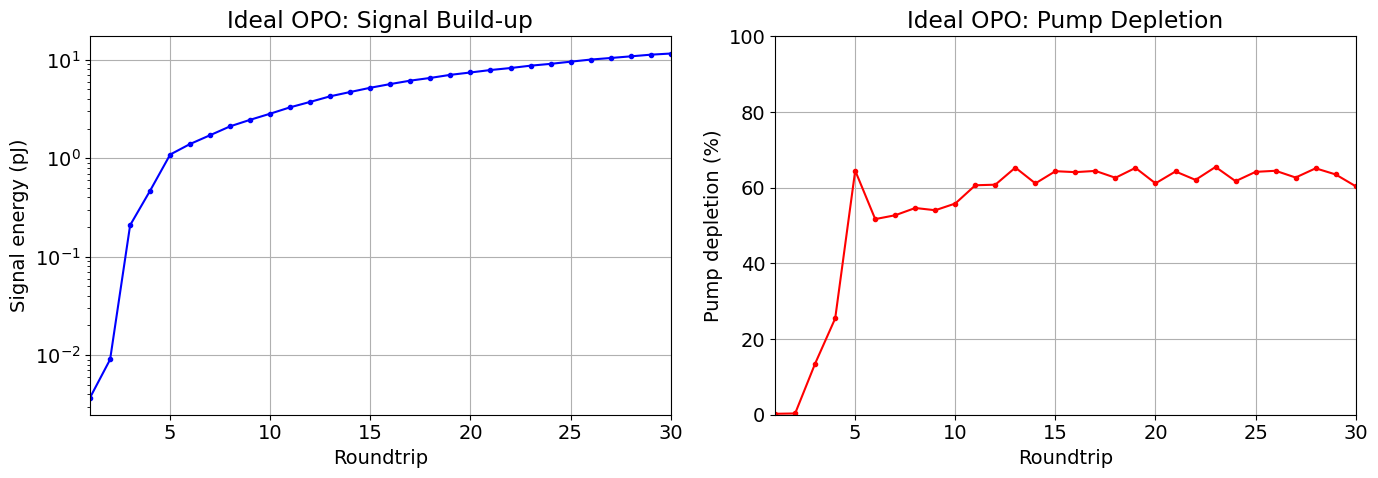

  RT   1: signal=3.7055e-03 pJ, pump depl=0.2%
  RT   2: signal=9.0297e-03 pJ, pump depl=0.3%
  RT   3: signal=2.0902e-01 pJ, pump depl=13.5%
  RT   4: signal=4.6908e-01 pJ, pump depl=25.4%
  RT   5: signal=1.0909e+00 pJ, pump depl=64.5%
  RT   6: signal=1.3978e+00 pJ, pump depl=51.7%
  RT   7: signal=1.7172e+00 pJ, pump depl=52.7%
  RT   8: signal=2.1126e+00 pJ, pump depl=54.6%
  RT   9: signal=2.4607e+00 pJ, pump depl=54.0%
  RT  10: signal=2.8391e+00 pJ, pump depl=55.8%
  RT  11: signal=3.2978e+00 pJ, pump depl=60.6%
  RT  12: signal=3.7417e+00 pJ, pump depl=60.8%
  RT  13: signal=4.2656e+00 pJ, pump depl=65.3%
  RT  14: signal=4.7147e+00 pJ, pump depl=61.1%
  RT  15: signal=5.2063e+00 pJ, pump depl=64.4%
  RT  16: signal=5.6765e+00 pJ, pump depl=64.1%
  RT  17: signal=6.1510e+00 pJ, pump depl=64.4%
  RT  18: signal=6.5521e+00 pJ, pump depl=62.6%
  RT  19: signal=7.0428e+00 pJ, pump depl=65.2%
  RT  20: signal=7.4419e+00 pJ, pump depl=61.1%
  RT  21: signal=7.8796e+00 pJ, pump depl=

In [5]:
n_rt = 30
sig_energy_ideal = np.zeros(n_rt)
pump_depl_ideal = np.zeros(n_rt)
recycled = pulses.noise(t, 0)

print('Ideal cavity (100% feedback, no loss):')

plt.ioff()
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), tight_layout=True)
line_sig, = ax1.semilogy([1], [1e-10], 'b.-')
ax1.set_xlabel('Roundtrip'); ax1.set_ylabel('Signal energy (pJ)')
ax1.set_title('Ideal OPO: Signal Build-up'); ax1.grid(True)
ax1.set_xlim(1, n_rt)
line_depl, = ax2.plot([1], [0], 'r.-')
ax2.set_xlabel('Roundtrip'); ax2.set_ylabel('Pump depletion (%)')
ax2.set_title('Ideal OPO: Pump Depletion'); ax2.grid(True)
ax2.set_xlim(1, n_rt); ax2.set_ylim(0, 100)
fig_handle = display(fig, display_id=True)
plt.ion()

t_total = time.perf_counter()
for rt in range(n_rt):
    pump_rt = pulses.sech_pulse(t, 100*fs, f_ref=f_ref, f0=c/(1*um),
                                Pavg=Pavg_pump, Npwr_dB=200, frep=frep)
    sig_pulse = pulses.pulse(t, recycled, c/f_ref, frep)
    input_rt = pump_rt + sig_pulse
    out_rt, _ = wg.propagate_NEE(input_rt, v_ref=v_ref, verbose=False,
                                 Qnoise=True, backend=BACKEND, **nee_kwargs)
    sig_rt = out_rt.apply_filter(f0_signal, signal_bw)
    pump_out = out_rt.apply_filter(c/(1*um), 40*THz)
    sig_energy_ideal[rt] = sig_rt.energy_td()
    pump_depl_ideal[rt] = 1 - pump_out.energy_td()/pump_rt.energy_td()
    recycled = sig_rt.a  # 100% feedback

    rts = np.arange(1, rt+2)
    line_sig.set_data(rts, sig_energy_ideal[:rt+1]/pJ)
    ax1.relim(); ax1.autoscale_view()
    line_depl.set_data(rts, pump_depl_ideal[:rt+1]*100)
    ax2.relim(); ax2.autoscale_view()
    fig_handle.update(fig)

    print(f'  RT {rt+1:3d}: signal={sig_energy_ideal[rt]/pJ:.4e} pJ, '
          f'pump depl={pump_depl_ideal[rt]:.1%}')

t_total = time.perf_counter() - t_total
if SHOW_TIMINGS:
    print(f'  [{BACKEND}] {t_total:.1f}s total, {t_total/n_rt:.2f}s per RT')

## 4. Add cavity loss

A real cavity has mirror losses, scattering, absorption.
The OPO only oscillates if single-pass gain exceeds round-trip loss.
Compare to the ideal case above.

Cavity with 15% round-trip loss, no outcoupling:


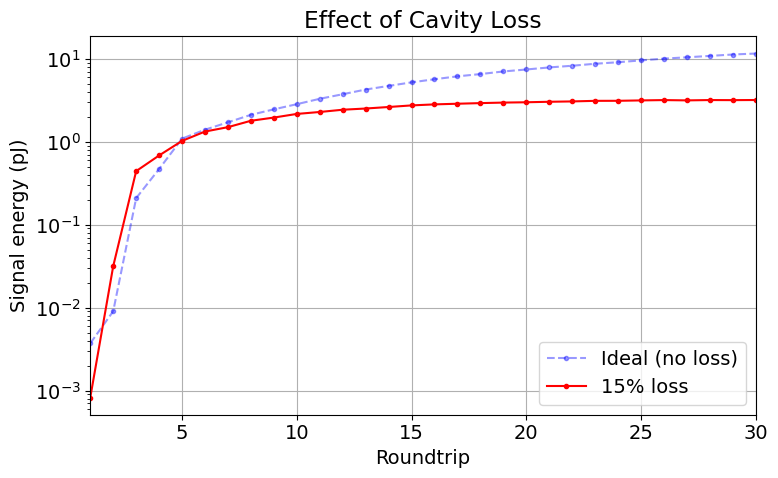

  RT   1: signal=8.2299e-04 pJ
  RT   2: signal=3.1587e-02 pJ
  RT   3: signal=4.4245e-01 pJ
  RT   4: signal=6.8369e-01 pJ
  RT   5: signal=1.0244e+00 pJ
  RT   6: signal=1.3278e+00 pJ
  RT   7: signal=1.5005e+00 pJ
  RT   8: signal=1.7916e+00 pJ
  RT   9: signal=1.9578e+00 pJ
  RT  10: signal=2.1659e+00 pJ
  RT  11: signal=2.2865e+00 pJ
  RT  12: signal=2.4342e+00 pJ
  RT  13: signal=2.5175e+00 pJ
  RT  14: signal=2.6258e+00 pJ
  RT  15: signal=2.7446e+00 pJ
  RT  16: signal=2.8234e+00 pJ
  RT  17: signal=2.8755e+00 pJ
  RT  18: signal=2.9250e+00 pJ
  RT  19: signal=2.9687e+00 pJ
  RT  20: signal=2.9945e+00 pJ
  RT  21: signal=3.0364e+00 pJ
  RT  22: signal=3.0661e+00 pJ
  RT  23: signal=3.1152e+00 pJ
  RT  24: signal=3.1191e+00 pJ
  RT  25: signal=3.1533e+00 pJ
  RT  26: signal=3.1819e+00 pJ
  RT  27: signal=3.1553e+00 pJ
  RT  28: signal=3.1847e+00 pJ
  RT  29: signal=3.1776e+00 pJ
  RT  30: signal=3.1886e+00 pJ
  [jax] 225.4s total


In [6]:
cavity_loss = 0.15  # 15% round-trip loss
n_rt = 30  # local default if cell 9 wasn't run
sig_energy_loss = np.zeros(n_rt)
recycled = pulses.noise(t, 0)

print(f'Cavity with {cavity_loss:.0%} round-trip loss, no outcoupling:')

plt.ioff()
fig, ax = plt.subplots(figsize=(8, 5), tight_layout=True)
try:
    ax.semilogy(range(1, n_rt+1), sig_energy_ideal/pJ, 'b.--', alpha=0.4, label='Ideal (no loss)')
except NameError:
    pass  # cell 9 wasn't run — skip overlay
line_loss, = ax.semilogy([1], [1e-10], 'r.-', label=f'{cavity_loss:.0%} loss')
ax.set_xlabel('Roundtrip'); ax.set_ylabel('Signal energy (pJ)')
ax.set_title('Effect of Cavity Loss'); ax.legend(); ax.grid(True)
ax.set_xlim(1, n_rt)
fig_handle = display(fig, display_id=True)
plt.ion()

t_total = time.perf_counter()
for rt in range(n_rt):
    pump_rt = pulses.sech_pulse(t, 100*fs, f_ref=f_ref, f0=c/(1*um),
                                Pavg=Pavg_pump, Npwr_dB=200, frep=frep)
    sig_pulse = pulses.pulse(t, recycled, c/f_ref, frep)
    input_rt = pump_rt + sig_pulse
    out_rt, _ = wg.propagate_NEE(input_rt, v_ref=v_ref, verbose=False,
                                 Qnoise=True, backend=BACKEND, **nee_kwargs)
    sig_rt = out_rt.apply_filter(f0_signal, signal_bw)
    sig_energy_loss[rt] = sig_rt.energy_td()
    recycled = sig_rt.a * np.sqrt(1 - cavity_loss)

    line_loss.set_data(np.arange(1, rt+2), sig_energy_loss[:rt+1]/pJ)
    ax.relim(); ax.autoscale_view()
    fig_handle.update(fig)

    print(f'  RT {rt+1:3d}: signal={sig_energy_loss[rt]/pJ:.4e} pJ')

t_total = time.perf_counter() - t_total
if SHOW_TIMINGS:
    print(f'  [{BACKEND}] {t_total:.1f}s total')

## 5. Add output coupler

Extract a fraction of the signal for use.  The output coupler adds
to the total round-trip loss but gives us useful output power.
Watch for the steady-state balance between gain and total loss.

In [ ]:
from IPython.display import display
import warnings as _w

outcoupling = 0.10   # 10% output coupler
cavity_loss = 0.05   # 5% parasitic loss
feedback_frac = 1 - outcoupling - cavity_loss
n_rt_oc = 60
GALLERY = False  # if True, plot spectrum+pulse for every roundtrip (scrollable)

sig_energy_oc = np.zeros(n_rt_oc)
pump_depl_oc = np.zeros(n_rt_oc)
out_power_oc = np.zeros(n_rt_oc)
recycled = pulses.noise(t, 0)

# Frequency grid for direct FFT filtering (bypasses pulse class fftshift issue)
f_abs_grid = fftfreq(N, t[1]-t[0]) + f_ref
DYN_RANGE = 60  # dB dynamic range for spectral plots

def bandpass_t7(A, center_freq, bw_Hz):
    """Filter in frequency domain, return time-domain field."""
    mask = np.abs(f_abs_grid - center_freq) < bw_Hz / 2
    return ifft(A * mask)

print(f'{outcoupling:.0%} outcoupling + {cavity_loss:.0%} loss = '
      f'{feedback_frac:.0%} feedback:')

# Set up live plot: 2x3 = pump/signal spectra + pump/signal temporal + build-up curves
plt.ioff()
fig, axes = plt.subplots(2, 3, figsize=(18, 10), tight_layout=True)
line_sig, = axes[0,0].semilogy([1], [1e-10], 'b.-')
axes[0,0].set_xlabel('Roundtrip'); axes[0,0].set_ylabel('Signal energy (pJ)')
axes[0,0].set_title('Signal Build-up'); axes[0,0].grid(True)
axes[0,0].set_xlim(1, n_rt_oc)

line_depl, = axes[0,1].plot([1], [0], 'r.-')
axes[0,1].set_xlabel('Roundtrip'); axes[0,1].set_ylabel('Pump depletion (%)')
axes[0,1].set_title('Pump Depletion'); axes[0,1].grid(True)
axes[0,1].set_xlim(1, n_rt_oc); axes[0,1].set_ylim(0, 100)

# Remaining 4 panels: pump spectrum, signal spectrum, pump temporal, signal temporal
axes[0,2].set_title('Pump spectrum'); axes[0,2].grid(True)
axes[1,0].set_title('Signal spectrum'); axes[1,0].grid(True)
axes[1,1].set_title('Pump temporal'); axes[1,1].grid(True)
axes[1,2].set_title('Signal temporal'); axes[1,2].grid(True)
fig_handle = display(fig, display_id=True)
plt.ion()

t_ps = t / ps
t_total = time.perf_counter()
for rt in range(n_rt_oc):
    pump_rt = pulses.sech_pulse(t, 100*fs, f_ref=f_ref, f0=c/(1*um),
                                Pavg=Pavg_pump, Npwr_dB=200, frep=frep)
    sig_pulse = pulses.pulse(t, recycled, c/f_ref, frep)
    input_rt = pump_rt + sig_pulse
    out_rt, _ = wg.propagate_NEE(input_rt, v_ref=v_ref, verbose=False,
                                 Qnoise=True, backend=BACKEND, **nee_kwargs)
    sig_rt = out_rt.apply_filter(f0_signal, signal_bw)
    pump_out = out_rt.apply_filter(c/(1*um), 40*THz)
    sig_energy_oc[rt] = sig_rt.energy_td()
    pump_depl_oc[rt] = 1 - pump_out.energy_td()/pump_rt.energy_td()
    out_power_oc[rt] = sig_energy_oc[rt] * outcoupling * frep
    recycled = sig_rt.a * np.sqrt(feedback_frac)

    # Update build-up curves
    rts = np.arange(1, rt+2)
    line_sig.set_data(rts, sig_energy_oc[:rt+1]/pJ)
    axes[0,0].relim(); axes[0,0].autoscale_view()
    line_depl.set_data(rts, pump_depl_oc[:rt+1]*100)
    axes[0,1].relim(); axes[0,1].autoscale_view()

    # Dichroic-filtered spectra and temporal profiles
    A_out = fft(out_rt.a)
    A_in = fft(input_rt.a)
    a_pump_out = bandpass_t7(A_out, c/(1*um), 40*THz)
    a_pump_in = bandpass_t7(A_in, c/(1*um), 40*THz)
    a_sig_out = bandpass_t7(A_out, f0_signal, signal_bw)
    a_sig_in = bandpass_t7(A_in, f0_signal, signal_bw)

    # Pump spectrum
    axes[0,2].clear()
    with _w.catch_warnings():
        _w.simplefilter('ignore')
        pump_rt.plot_PSD(ax=axes[0,2], f_unit='um')
        axes[0,2].get_lines()[-1].set(color='k', linestyle='--', alpha=0.3, label='Input')
        out_rt.plot_PSD(ax=axes[0,2], f_unit='um')
        axes[0,2].get_lines()[-1].set(color='g', linewidth=1.5, label='Output')
    axes[0,2].set_xlim(0.85, 1.2)
    ydata = axes[0,2].get_lines()[-1].get_ydata()
    ymax = np.nanmax(ydata[np.isfinite(ydata)])
    axes[0,2].set_ylim(ymax - DYN_RANGE, ymax + 5)
    axes[0,2].legend(fontsize=9); axes[0,2].set_title(f'Pump spectrum (RT {rt+1})')

    # Signal spectrum
    axes[1,0].clear()
    with _w.catch_warnings():
        _w.simplefilter('ignore')
        out_rt.plot_PSD(ax=axes[1,0], f_unit='um')
        axes[1,0].get_lines()[-1].set(color='b', linewidth=1.5, label='Output')
    axes[1,0].set_xlim(1.5, 2.8)
    ydata = axes[1,0].get_lines()[-1].get_ydata()
    ymax = np.nanmax(ydata[np.isfinite(ydata)])
    axes[1,0].set_ylim(ymax - DYN_RANGE, ymax + 5)
    axes[1,0].legend(fontsize=9); axes[1,0].set_title(f'Signal spectrum (RT {rt+1})')

    # Pump temporal
    axes[1,1].clear()
    axes[1,1].plot(t_ps, np.abs(a_pump_in)**2, 'k--', alpha=0.3, label='Input')
    axes[1,1].plot(t_ps, np.abs(a_pump_out)**2, 'g', linewidth=1.5, label='Output')
    axes[1,1].set_xlim(-0.5, 1.5); axes[1,1].set_xlabel('Time (ps)')
    axes[1,1].set_ylabel('Power (W)'); axes[1,1].grid(True)
    axes[1,1].legend(fontsize=9); axes[1,1].set_title(f'Pump temporal (RT {rt+1})')

    # Signal temporal
    axes[1,2].clear()
    axes[1,2].plot(t_ps, np.abs(a_sig_out)**2, 'b', linewidth=1.5, label='Signal')
    axes[1,2].set_xlim(-0.5, 1.5); axes[1,2].set_xlabel('Time (ps)')
    axes[1,2].set_ylabel('Power (W)'); axes[1,2].grid(True)
    axes[1,2].legend(fontsize=9); axes[1,2].set_title(f'Signal temporal (RT {rt+1})')

    fig_handle.update(fig)

    # Optional: static gallery
    if GALLERY:
        fig_g, gax = plt.subplots(1, 4, figsize=(20, 4), tight_layout=True)
        with _w.catch_warnings():
            _w.simplefilter('ignore')
            out_rt.plot_PSD(ax=gax[0], f_unit='um')
        gax[0].set_xlim(0.85, 1.2); gax[0].set_title(f'RT {rt+1} Pump spec')
        with _w.catch_warnings():
            _w.simplefilter('ignore')
            out_rt.plot_PSD(ax=gax[1], f_unit='um')
        gax[1].set_xlim(1.5, 2.8); gax[1].set_title(f'RT {rt+1} Signal spec')
        gax[2].plot(t_ps, np.abs(a_pump_out)**2, 'g')
        gax[2].set_xlim(-0.5, 1.5); gax[2].set_title(f'RT {rt+1} Pump')
        gax[3].plot(t_ps, np.abs(a_sig_out)**2, 'b')
        gax[3].set_xlim(-0.5, 1.5); gax[3].set_title(f'RT {rt+1} Signal')
        plt.show()

    print(f'  RT {rt+1:3d}: signal={sig_energy_oc[rt]/pJ:.4e} pJ, '
          f'pump depl={pump_depl_oc[rt]:.1%}, '
          f'output={out_power_oc[rt]/uW:.3f} uW')

t_total = time.perf_counter() - t_total
if SHOW_TIMINGS:
    print(f'  [{BACKEND}] {t_total:.1f}s total, {t_total/n_rt_oc:.2f}s per RT')

ss = slice(-10, None)
print(f'\nSteady state: signal={np.mean(sig_energy_oc[ss])/pJ:.3f} pJ, '
      f'pump depl={np.mean(pump_depl_oc[ss]):.1%}, '
      f'output={np.mean(out_power_oc[ss])/uW:.2f} uW')

## 6. Effect of cavity detuning

In a synchronously-pumped OPO, the cavity round-trip time must match
the pump repetition period.  A timing offset (detuning) shifts the
returning signal relative to the next pump, reducing temporal overlap
and hence parametric gain.

Even a few femtoseconds matters for 100 fs pulses.

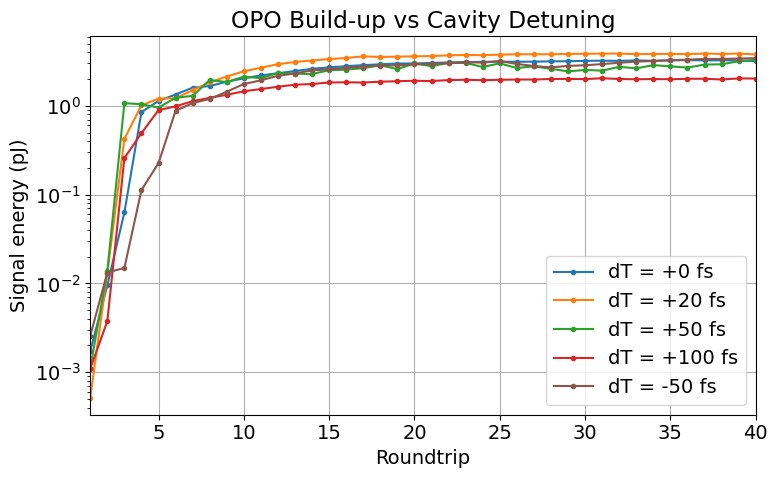

  RT   1: 1.74e-03  5.19e-04  1.11e-03  1.10e-03  2.57e-03
  RT   2: 9.48e-03  1.31e-02  1.38e-02  3.75e-03  1.33e-02
  RT   3: 6.31e-02  4.26e-01  1.07e+00  2.58e-01  1.49e-02
  RT   4: 8.49e-01  1.01e+00  1.04e+00  4.92e-01  1.13e-01
  RT   5: 1.13e+00  1.21e+00  9.54e-01  8.94e-01  2.26e-01
  RT   6: 1.34e+00  1.22e+00  1.23e+00  9.86e-01  8.79e-01
  RT   7: 1.60e+00  1.50e+00  1.29e+00  1.13e+00  1.07e+00
  RT   8: 1.67e+00  1.83e+00  1.95e+00  1.23e+00  1.19e+00
  RT   9: 1.87e+00  2.14e+00  1.85e+00  1.33e+00  1.44e+00
  RT  10: 2.04e+00  2.45e+00  2.13e+00  1.46e+00  1.76e+00
  RT  11: 2.20e+00  2.69e+00  2.04e+00  1.54e+00  1.93e+00
  RT  12: 2.33e+00  2.94e+00  2.34e+00  1.64e+00  2.18e+00
  RT  13: 2.46e+00  3.11e+00  2.30e+00  1.73e+00  2.31e+00
  RT  14: 2.61e+00  3.23e+00  2.28e+00  1.76e+00  2.51e+00
  RT  15: 2.71e+00  3.36e+00  2.51e+00  1.83e+00  2.57e+00
  RT  16: 2.79e+00  3.45e+00  2.56e+00  1.84e+00  2.68e+00
  RT  17: 2.87e+00  3.60e+00  2.65e+00  1.83e+00  2.76e+

In [8]:
detunings = [0, 20*fs, 50*fs, 100*fs, -50*fs]
n_rt_dt = 40

# Cavity params (self-contained)
oc_dt = 0.10; loss_dt = 0.05
fb_dt = 1 - oc_dt - loss_dt

colors_dt = plt.cm.tab10(np.linspace(0, 0.5, len(detunings)))

plt.ioff()
fig, ax = plt.subplots(figsize=(8, 5), tight_layout=True)
ax.set_xlabel('Roundtrip'); ax.set_ylabel('Signal energy (pJ)')
ax.set_title('OPO Build-up vs Cavity Detuning')
ax.set_xlim(1, n_rt_dt); ax.grid(True)
lines_dt = {}
for i, dT in enumerate(detunings):
    lines_dt[i], = ax.semilogy([1], [1e-10], '.-', color=colors_dt[i],
                                label=f'dT = {dT/fs:+.0f} fs')
ax.legend()
fig_handle = display(fig, display_id=True)
plt.ion()

# State for each detuning
energies_dt = np.zeros((len(detunings), n_rt_dt))
recycled_dt = [pulses.noise(t, 0) for _ in detunings]

t_total = time.perf_counter()

# Outer loop: roundtrips. All detunings advance together.
for rt in range(n_rt_dt):
    for i, dT in enumerate(detunings):
        pump = pulses.sech_pulse(t, 100*fs, f_ref=f_ref, f0=c/(1*um),
                                 Pavg=Pavg_pump, Npwr_dB=200, frep=frep)
        sig_p = pulses.pulse(t, recycled_dt[i], c/f_ref, frep)
        if dT != 0:
            pulses.add_t_offset(sig_p, dT)
        inp = pump + sig_p
        out, _ = wg.propagate_NEE(inp, v_ref=v_ref, verbose=False,
                                  Qnoise=True, backend=BACKEND, **nee_kwargs)
        sig = out.apply_filter(f0_signal, signal_bw)
        energies_dt[i, rt] = sig.energy_td()
        recycled_dt[i] = sig.a * np.sqrt(fb_dt)

        lines_dt[i].set_data(np.arange(1, rt+2), energies_dt[i, :rt+1]/pJ)

    ax.relim(); ax.autoscale_view()
    fig_handle.update(fig)

    vals = '  '.join(f'{energies_dt[i,rt]/pJ:.2e}' for i in range(len(detunings)))
    print(f'  RT {rt+1:3d}: {vals}')

t_total = time.perf_counter() - t_total

print()
for i, dT in enumerate(detunings):
    ss_e = np.mean(energies_dt[i, -5:])
    print(f'  dT={dT/fs:+5.0f} fs: steady-state = {ss_e/pJ:.3f} pJ')
if SHOW_TIMINGS:
    print(f'  [{BACKEND}] {t_total:.1f}s total')

## 7. Threshold scan

Sweep pump power to find the OPO threshold — the minimum power
where round-trip parametric gain exceeds the total cavity loss
(parasitic + outcoupling).

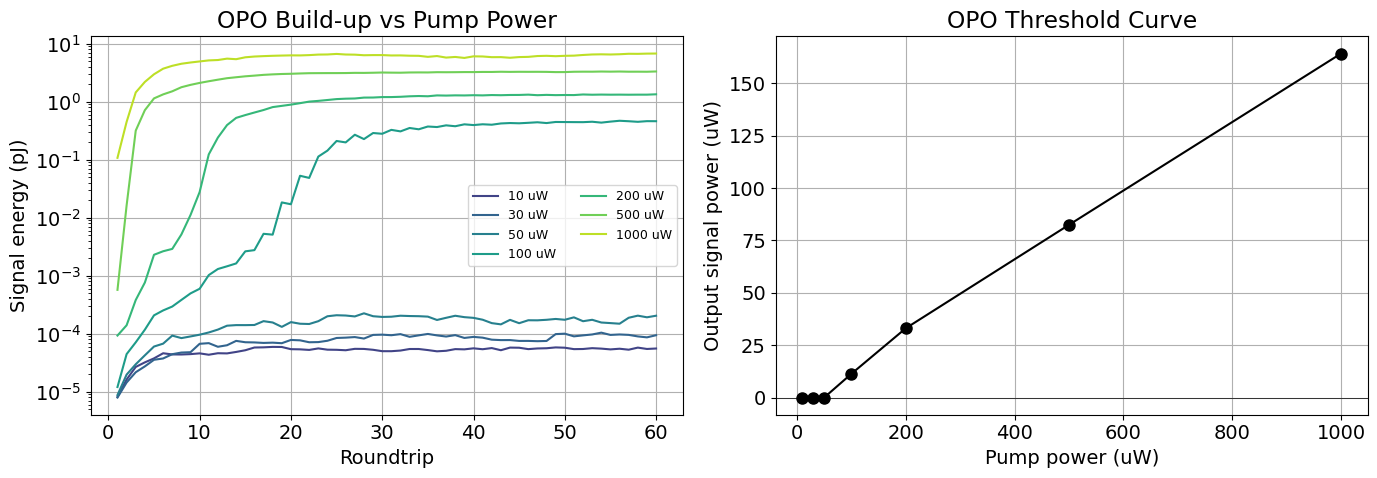

  Ppump=    10 uW: output=0.0014 uW
  Ppump=    30 uW: output=0.0024 uW
  Ppump=    50 uW: output=0.0045 uW
  Ppump=   100 uW: output=11.3408 uW
  Ppump=   200 uW: output=33.0995 uW
  Ppump=   500 uW: output=82.4976 uW
  Ppump=  1000 uW: output=164.2847 uW
  [jax] 2615.3s total


In [9]:
from IPython.display import display

P_thresh = np.array([10, 30, 50, 100, 200, 500, 1000]) * uW
n_rt_thresh = 60

# Self-contained cavity params
oc_th = 0.10; loss_th = 0.05
fb_th = 1 - oc_th - loss_th

plt.ioff()
fig_th, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), tight_layout=True)
ax1.set_xlabel('Roundtrip'); ax1.set_ylabel('Signal energy (pJ)')
ax1.set_title('OPO Build-up vs Pump Power')
ax1.set_yscale('log'); ax1.grid(True)
ax2.set_xlabel('Pump power (uW)'); ax2.set_ylabel('Output signal power (uW)')
ax2.set_title('OPO Threshold Curve'); ax2.grid(True)
fig_handle = display(fig_th, display_id=True)
plt.ion()

ss_powers = []
colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(P_thresh)))
t_total = time.perf_counter()

for ip, Pp in enumerate(P_thresh):
    recycled = pulses.noise(t, 0)
    energies = np.zeros(n_rt_thresh)
    for rt in range(n_rt_thresh):
        pump = pulses.sech_pulse(t, 100*fs, f_ref=f_ref, f0=c/(1*um),
                                 Pavg=Pp, Npwr_dB=200, frep=frep)
        sig_p = pulses.pulse(t, recycled, c/f_ref, frep)
        inp = pump + sig_p
        out, _ = wg.propagate_NEE(inp, v_ref=v_ref, verbose=False,
                                  Qnoise=True, backend=BACKEND, **nee_kwargs)
        sig = out.apply_filter(f0_signal, signal_bw)
        energies[rt] = sig.energy_td()
        recycled = sig.a * np.sqrt(fb_th)

    ss_power = np.mean(energies[-10:]) * oc_th * frep
    ss_powers.append(ss_power)
    ax1.semilogy(np.arange(1, n_rt_thresh+1), energies/pJ,
                 color=colors[ip], label=f'{Pp/uW:.0f} uW')
    ax1.legend(fontsize=9, ncol=2)
    fig_handle.update(fig_th)
    print(f'  Ppump={Pp/uW:6.0f} uW: output={ss_power/uW:.4f} uW')

t_total = time.perf_counter() - t_total
if SHOW_TIMINGS:
    print(f'  [{BACKEND}] {t_total:.1f}s total')

ax2.plot(P_thresh/uW, np.array(ss_powers)/uW, 'ko-', markersize=8)
ax2.axhline(y=0, color='k', linewidth=0.5)
fig_handle.update(fig_th)

## Summary

We built up the OPO physics layer by layer:

1. **OPA** — pure parametric gain from a coherent seed
2. **Fluorescence** — add vacuum noise; spontaneous emission seeds the process
3. **Ideal cavity** — add feedback; signal grows until pump depletion
4. **Cavity loss** — raises threshold, slows build-up
5. **Output coupler** — extracts signal; steady-state emerges from gain = loss
6. **Cavity detuning** — timing sensitivity; few-fs offsets affect the OPO
7. **Threshold scan** — mapping power vs output to find oscillation onset

Each step adds one effect, with the previous curve shown for comparison
where relevant.

Set `BACKEND = 'jax'` in the first cell for GPU acceleration.